이 데이터셋을 통해서, 고객들에게 자동차보험 크로스셀을 제안하려고 합니다.  
어떤 고객이 과연 자동차 보험을 가입할 가능성이 높을까요

# Data Load

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#지수표기법 X
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [5]:
try:
    # 윈도우 환경 (D 드라이브)
    train = pd.read_csv('D:/train.csv')
    test = pd.read_csv('D:/test.csv')
    sample_submission = pd.read_csv('D:/sample_submission.csv')
except: 
    # 맥 환경
    base_path = '/Users/baeknamjin/Downloads/binary-classification-of-insurance-cross-selling/'
    
    train = pd.read_csv(base_path + 'train.csv')
    test = pd.read_csv(base_path + 'test.csv')
    # 아래 줄 오타 수정됨 (경로 사이에 / 확인)
    sample_submission = pd.read_csv(base_path + 'sample_submission.csv')

# Variable Description

| Feature Name | Type | Description |
|---|---|---|
| id | Continuous | 고객 고유 식별자 |
| Age | Continuous | 고객의 나이 |
| Gender | Dichotomous | 고객의 성별 |
| Driving_License | Dichotomous | 0: 운전면허 없음, 1: 운전면허 있음 |
| Region_Code | Nominal | 고객 지역의 고유 코드 |
| Previously_Insured | Dichotomous | 0: 차량 보험 미가입, 1: 차량 보험 가입 |
| Vehicle_Age | Nominal | 차량 연식 |
| Vehicle_Damage | Dichotomous | 0: 과거 차량 사고 없음, 1: 과거 차량 사고 있음 |
| Annual_Premium | Continuous | 고객이 연간 납부해야 하는 보험료 |
| Policy_Sales_Channel | Nominal | 고객 접촉 채널의 익명화된 코드 (영업사원, 이메일, 전화, 대면 등) |
| Vintage | Continuous | 고객이 회사와 거래한 기간 (일 단위) |
| **Response** (Target) | Dichotomous | 1: 고객 관심 있음, 0: 고객 관심 없음 |

# Data Wrangling

In [6]:
train.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,0,Male,21,1,35.000,0,1-2 Year,Yes,65101.000,124.000,187,0
1,1,Male,43,1,28.000,0,> 2 Years,Yes,58911.000,26.000,288,1
2,2,Female,25,1,14.000,1,< 1 Year,No,38043.000,152.000,254,0
3,3,Female,35,1,1.000,0,1-2 Year,Yes,2630.000,156.000,76,0
4,4,Female,36,1,15.000,1,1-2 Year,No,31951.000,152.000,294,0


In [7]:
train.shape

(11504798, 12)

In [8]:
train.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,11504798.000,11504798.000,11504798.000,11504798.000,11504798.000,11504798.000,11504798.000,11504798.000,11504798.000
mean,5752398.500,38.384,0.998,26.419,0.463,30461.370,112.425,163.898,0.123
std,3321149.255,14.993,0.044,12.992,0.499,16454.745,54.036,79.980,0.328
min,0.000,20.000,0.000,0.000,0.000,2630.000,1.000,10.000,0.000
25%,2876199.250,24.000,1.000,15.000,0.000,25277.000,29.000,99.000,0.000
50%,5752398.500,36.000,1.000,28.000,0.000,31824.000,151.000,166.000,0.000
75%,8628597.750,49.000,1.000,35.000,1.000,39451.000,152.000,232.000,0.000
max,11504797.000,85.000,1.000,52.000,1.000,540165.000,163.000,299.000,1.000


**Insight**

- Annual_premium 변수에서 연 5천 만원을 내는 사람있음.

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11504798 entries, 0 to 11504797
Data columns (total 12 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   Gender                object 
 2   Age                   int64  
 3   Driving_License       int64  
 4   Region_Code           float64
 5   Previously_Insured    int64  
 6   Vehicle_Age           object 
 7   Vehicle_Damage        object 
 8   Annual_Premium        float64
 9   Policy_Sales_Channel  float64
 10  Vintage               int64  
 11  Response              int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 1.0+ GB


In [10]:
# 일단 먼저 수치형, 범주형 변수 분리
num_cols = train.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('id')  # id 컬럼 제외
cat_cols = train.select_dtypes(include='object').columns.tolist()

# 데이터 탐색해보기

In [11]:
# num_cols
num_cols

['Age',
 'Driving_License',
 'Region_Code',
 'Previously_Insured',
 'Annual_Premium',
 'Policy_Sales_Channel',
 'Vintage',
 'Response']

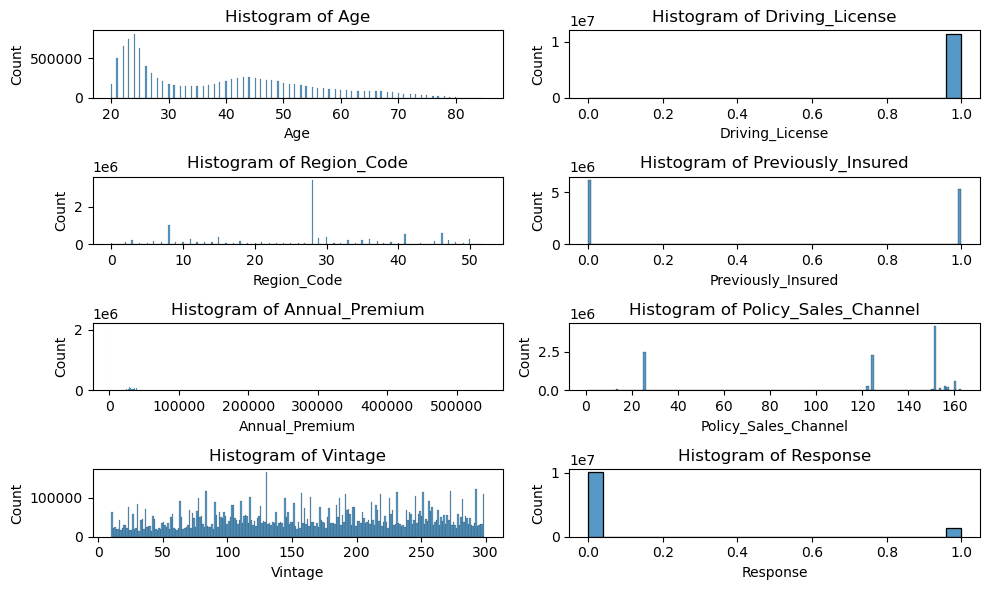

In [12]:
# 수치형 변수 히스토그램
plt.figure(figsize=(10, 6))
i = 0
for col in num_cols:
    i += 1
    plt.subplot(4, 2, i)
    sns.histplot(train[col])
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()


In [13]:
(train['Driving_License'].value_counts() / len(train)) * 100

Driving_License
1   99.802
0    0.198
Name: count, dtype: float64

**Insight**

- 20~30대가 많이 분포되어있음 
- 해당 데이터셋에는 99.8%가 운전면허증을 가지고 있음. 운전면허증이 없는 사람들은 자동차 보험 크로스셀에 관심 없지 않을까? 또는 추후에 곧 차량 구매하려고 하는 사람이 있다면 관심있지 않을까?
- previously_insured 차량 보험 미가입과 차량 보험 가입자의 비율은 비슷함
- Annual_premium에 이상값이 있음 (전처리 필요)
- Response 변수에 자동차 보험에 관심없는 비율이 훨씬 많음

In [14]:
# 연령별 연 보혐료 분포를 확인해서, 고객이 관심이 있는지 확인
# 가설 - 나이가 많을수록 연 보험료가 높기에, 구매력이 있기 때문에,
# 자동차 보험 가입하는 것에 어느정도 관심이 있을것이다.

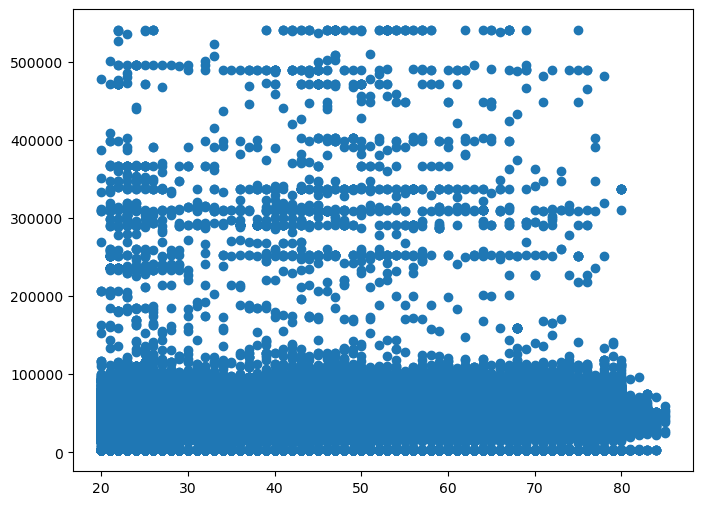

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(train['Age'], train['Annual_Premium'])

**Insight**
- 연령이 높을수록, 연 보험료가 높을 것이라 생각했는데, 아니다. 상관관계가 없어보인다.

In [16]:
# 운전면허가 있는 사람과 없는 사람별로 자동차 보험 관심있는지 확인
plt.figure(figsize=(8,6))
pd.crosstab(train['Driving_License'], train['Response'], normalize='index')

Response,0,1
Driving_License,,
0,0.945,0.055
1,0.877,0.123


<Figure size 800x600 with 0 Axes>

**Insight**

- 운전면허가 없는데, 관심있다고 한 비율은 약 5%
- 운전면허가 있는데, 관심있다고 한 비율은 약 12%
> 이 두 가지 범주에 속하는 고객(총 17%)이 주 타겟이 되겠다. 그들에게 집중적으로 설득을 진행한다.

- 운전면허가 있는데, 관심 없다고 한 비율은 약 87%
> 건강보험은 본 회사걸로 들고 있지만, 본 회사의 자동차 보험에는 관심이 없는 경우가 되겠다. 타 회사의 자동차 보험을 들고 있는 경우가 있을 것이다.

그렇다면 추가로, 관심없다고 한 비율 분들을 대상으로, 실제로 기존에 차량보험에 가입되어있는지, 아님 본 회사의 자동차 보험이 필요하지 않은건지 봐야겠다.


In [17]:
# 차량 보험에 가입되어 있는 사람과 안되어있는 사람의 관심도

plt.figure(figsize=(8, 6))
pd.crosstab(train['Previously_Insured'], train['Response'], normalize='index').round(4)


Response,0,1
Previously_Insured,,
0,0.771,0.229
1,0.999,0.001


<Figure size 800x600 with 0 Axes>

**Insight**
- 차량보험이 있으니 관심이 없다. 1%의 관심 고객은 뭘까?
> 한국 기준으로, 손해보험의 원칙인 '두 개 이상의 자동차보험은 가입이 불가능하다' 그럼 1%는 오입력일 것이고, 미국 기준으로, 중복 가입이 합법이나 권장하지 않는다고 한다. 이들은 우리 상품을 소개할 고객에서 제외한다.

- 차량보험이 없는데, 관심이 있는 사람의 비율이 약 23%다. 이후에 차량을 운전할 예정일 사람일 수 있따.

우리 회사의 자동차 보험을 판매하기 위해선, 일단 저 1%의 고객은 제외한다.

In [18]:
# 차량 사고를 낸 경험이 있는 사람이라면, 자동차 보험에 관심이 있지 않을까?

plt.figure(figsize=(8, 6))
pd.crosstab([train['Driving_License'], train['Previously_Insured'], train['Vehicle_Damage']], 
            train['Response']).style.background_gradient(cmap='coolwarm')


<Figure size 800x600 with 0 Axes>

**Insight**
- 운전면허 있고, 자동차 보험은 없고, 이전에 사고를 낸 경험이 있는 사람이 큰 관심을 가진다. (1387977명)

- 운전면허 있고, 자동차 보험은 없고, 이전에 사고를 낸 경험이 없는 사람이 큰 관심을 가진다. (22432명)

- 운전면허 없고, 자동차 보험도 가입이 되어있지않고, 이전에 사고를 낸 경험이 있는 사람이 관심을 가진다. (1240명)

# 상관관계 파악

<Axes: >

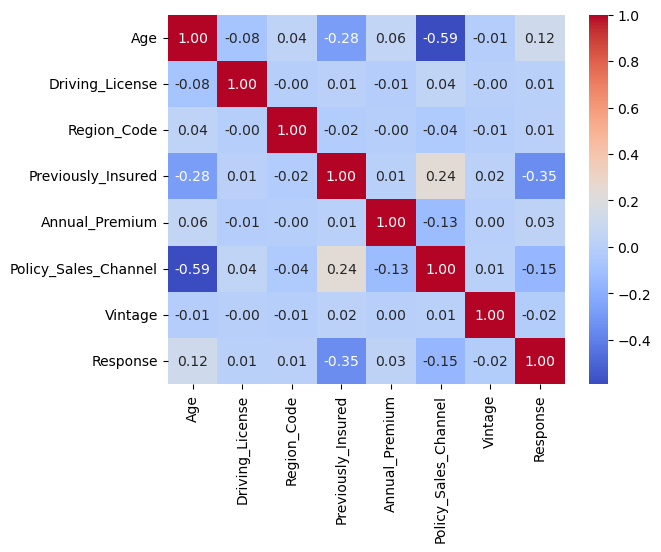

In [19]:
sns.heatmap(train[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')

**Insight**

- Policy Sales Channel이랑 Age가 음의 상관관계를 보이는데, 이는 해석하기 어렵다. 나이가 어린 사람에게는 비대면? 나이가 많은 사람에게는 대면? 이런 식으로 제공했다면 우연히 음이 상관관계가 나올 수 있다. 이 변수는 구체적인 설명이 필요하다.

- 약한 상관관계를 보이는 변수 묶음이 있지만, 위 탐색적 데이터 분석 crosstab으로 어느정도 알고 있는 사실이다.

- Vintage(고객이 회사와 거래한 기간)과 Response 관계를 보면, 회사와 거래한 기간이 오래되었다고 해도 본 회사의 자동차 보험에 그닥 관심 없다.

(array([0, 1, 2]),
 [Text(0, 0, '1-2 Year'), Text(1, 0, '< 1 Year'), Text(2, 0, '> 2 Years')])

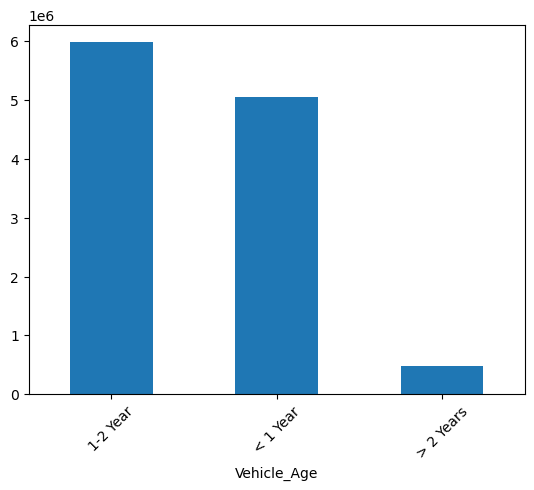

In [20]:
train['Vehicle_Age'].value_counts().plot(kind='bar')
plt.xticks(rotation=45)

In [21]:
# 차량 연식에 따른 자동차 보험 관심도
# 가설 - 차량 연식이 낮을수록(새차일수록) 자동차 보험에 관심이 있을것이다.

pd.crosstab(train['Vehicle_Age'], train['Response'], normalize='index').style.background_gradient(cmap='coolwarm')

Response,0,1
Vehicle_Age,,
1-2 Year,0.822275,0.177725
< 1 Year,0.958596,0.041404
> 2 Years,0.700951,0.299049


**Insight**

- 차량연식이 1년 미만인 경우 4%정도만 관심있어한다.
- 1-2년인 경우, 약 18%가 관심있어한다.
- 2년 이상인 경우, 약 30%가 관심있어한다.

> 양의 상관관계를 띈다. 차량 연식이 오래된 경우 자동차 보험을 더 들려고 한다. 
- 오래된 차는 고장이나 사고 위험이 높은 점
- 기존 보험 갱신 시기 가능성

> 비즈니스 전략으로, 2년 이상된 차량 소유자에게 후킹 메시지와 함께, 집중 마케팅 하는 방법이 되겠다.

In [56]:
train.columns

Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='object')

In [ ]:
pd.crosstab([train['Vehicle_Age'], train['Previously_Insured']], train['Response'], normalize='index').style.background_gradient(cmap='coolwarm')

**Insight**

- 차량연식이 1-2년이고, 자동차 보험 미가입인 경우 관심을 가지는 정도가 26%
- 차량 연식이 2년 이상이고, 자동차 보험 미가입인 경우 관심 가지는 정도가 약 30%

> 이들을 대상으로 본격적으로 마케팅을 진행한다.

# 정리

#### 기존 차량보험 가입 여부 (가장 중요)
- 이미 차량보험 있는 사람: 99.9% 관심 없음 → 마케팅 대상 제외
- 차량보험 없는 사람: 22.9% 관심 있음 → 핵심 타겟층

#### 과거 사고 경험
- 사고 경험 있는 사람이 보험에 훨씬 더 관심 많음
- 주요 타겟 고객군:
  - 운전면허 O + 차량보험 X + 사고 경험 O → **1,387,977명** (최우선 타겟)
  - 운전면허 O + 차량보험 X + 사고 경험 O → 22,432명
  - 운전면허 X + 차량보험 X + 사고 경험 O → 1,240명

#### 차량 연식
- 1년 미만 새 차: 4% 관심
- 1-2년 차: 18% 관심
- 2년 이상 오래된 차: 30% 관심
- **차가 오래될수록 보험 가입 의향 급증** (7.5배 차이)

#### 운전면허
- 면허 없는 사람: 5.5% 관심
- 면허 있는 사람: 12.3% 관심
- 전체의 99.8%가 면허 보유


# 마케팅 전략은?
1. 운전면허를 보유하고 있고, 기존 차량 보험에 미가입되어있으며, 과거 사고 경험이 있으며, 차량 연식 2년 이상인 경우

> Action
- 사고 경험이 있으시니 보험이 더욱 필요하다는 메세지 전달
- 오래된 차량일수록 위험 증가! 한다는 경고?를 주는 메세지 필요
- 이분들에겐 집중 인바운드 영업 (어떻게든 만나야겠다!!!!)


2. 운전면허를 보유하고 있고, 기존 차량보험 미가입되어 있고, 과고 사고 경험이 있으며, 차량 연식 1~2년 사이

> Action
- 중간 우산순위 영업
- 디지털 마케팅 채널 활용해서 리소스 줄이기

### 즉시 실행해야할 것은?
1. Tier 1 타겟 고객(139만 명)에게 집중 마케팅 캠페인 시작
2. 메시지 차별화
   - 사고 경험자: "이미 경험하셨죠? 이번엔 대비하세요"
   - 오래된 차량: "2년 이상 된 차량, 보험료 인상 전에 가입하세요"
3. 기존 차량보험 가입자 마케팅 중단

### 중기 전략
1. 판매 채널(Policy_Sales_Channel)별 효과성 분석
2. 지역(Region_Code)별 맞춤 전략 수립
3. A/B 테스트를 통한 최적 마케팅 믹스 도출